# Loan Risk Analysis
**Dataset:** German Credit Risk  
**Source:** UCI Machine Learning Repository  
**Goal:** Analyze patterns and risk factors associated with loan default

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Load Dataset

In [14]:
# UCI dataset: space-separated, no header
df = pd.read_csv('../data/raw/german_credit.csv', sep=' ', header=None)

# Rename columns for readability
df.columns = [
    'checking_account', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings_account', 'employment', 'installment_rate', 'personal_status',
    'other_debtors', 'residence_since', 'property', 'age', 'other_plans',
    'housing', 'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker', 'risk'
]

# Map risk: 1 = Good, 2 = Bad
df['risk'] = df['risk'].map({1: 'Good', 2: 'Bad'})

print(f'Shape: {df.shape}')
df.head()

Shape: (1000, 21)


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,Good
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,Bad
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,Good
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,Good
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,Bad


## 2. Data Overview

In [15]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df.describe()

=== Data Types ===
checking_account    object
duration             int64
credit_history      object
purpose             object
credit_amount        int64
savings_account     object
employment          object
installment_rate     int64
personal_status     object
other_debtors       object
residence_since      int64
property            object
age                  int64
other_plans         object
housing             object
existing_credits     int64
job                 object
dependents           int64
telephone           object
foreign_worker      object
risk                object
dtype: object

=== Missing Values ===
checking_account    0
duration            0
credit_history      0
purpose             0
credit_amount       0
savings_account     0
employment          0
installment_rate    0
personal_status     0
other_debtors       0
residence_since     0
property            0
age                 0
other_plans         0
housing             0
existing_credits    0
job                 0
de

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


## 3. Chart: Loan Risk Distribution

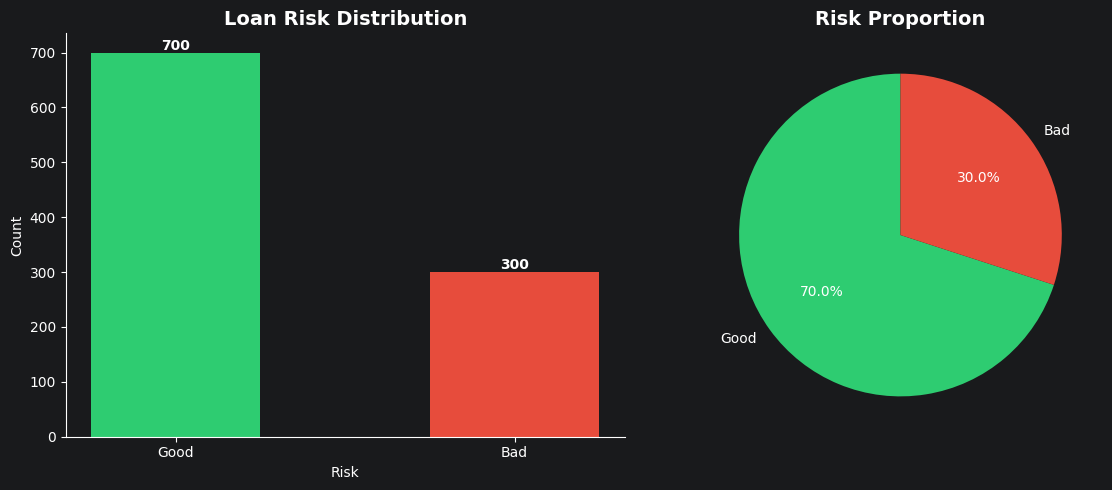

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
risk_counts = df['risk'].value_counts()
axes[0].bar(risk_counts.index, risk_counts.values, color=['#2ecc71', '#e74c3c'], width=0.5)
axes[0].set_title('Loan Risk Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk')
axes[0].set_ylabel('Count')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Risk Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Chart: Credit Amount Distribution by Risk

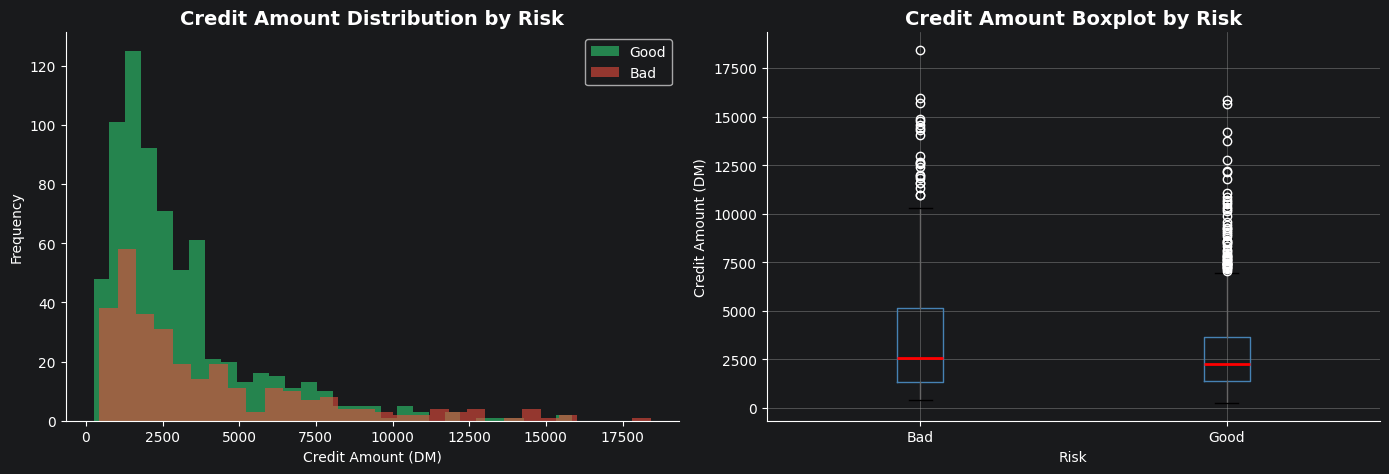

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for risk, color in zip(['Good', 'Bad'], ['#2ecc71', '#e74c3c']):
    axes[0].hist(df[df['risk'] == risk]['credit_amount'], bins=30,
                 alpha=0.6, label=risk, color=color)
axes[0].set_title('Credit Amount Distribution by Risk', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Credit Amount (DM)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot
df.boxplot(column='credit_amount', by='risk', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Credit Amount Boxplot by Risk', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Risk')
axes[1].set_ylabel('Credit Amount (DM)')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 5. Chart: Age Distribution by Risk

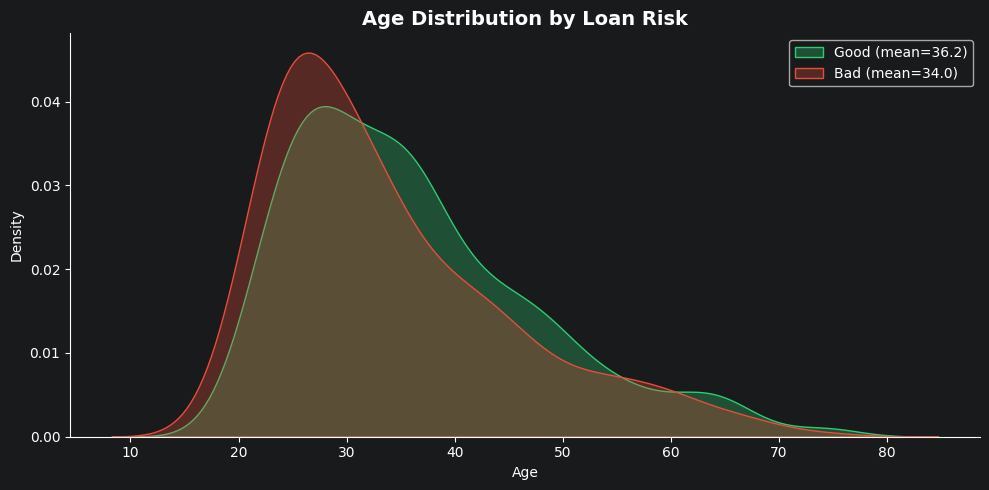

In [19]:
plt.figure(figsize=(10, 5))

for risk, color in zip(['Good', 'Bad'], ['#2ecc71', '#e74c3c']):
    subset = df[df['risk'] == risk]['age']
    sns.kdeplot(subset, label=f'{risk} (mean={subset.mean():.1f})', color=color, fill=True, alpha=0.3)

plt.title('Age Distribution by Loan Risk', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Chart: Loan Duration vs Credit Amount

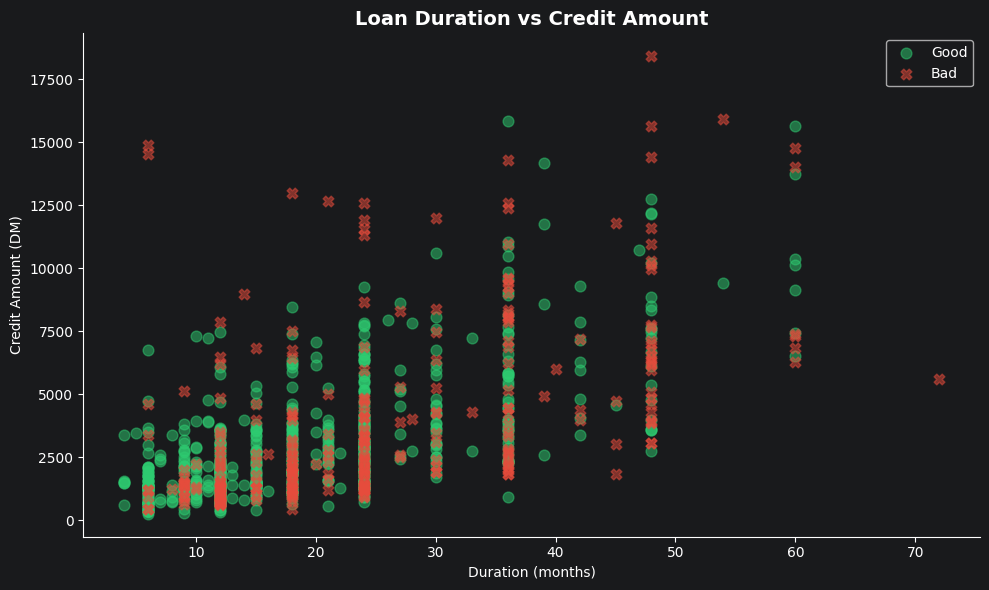

In [20]:
plt.figure(figsize=(10, 6))

for risk, color, marker in zip(['Good', 'Bad'], ['#2ecc71', '#e74c3c'], ['o', 'X']):
    subset = df[df['risk'] == risk]
    plt.scatter(subset['duration'], subset['credit_amount'],
                alpha=0.5, label=risk, color=color, marker=marker, s=60)

plt.title('Loan Duration vs Credit Amount', fontsize=14, fontweight='bold')
plt.xlabel('Duration (months)')
plt.ylabel('Credit Amount (DM)')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Chart: Risk by Credit History

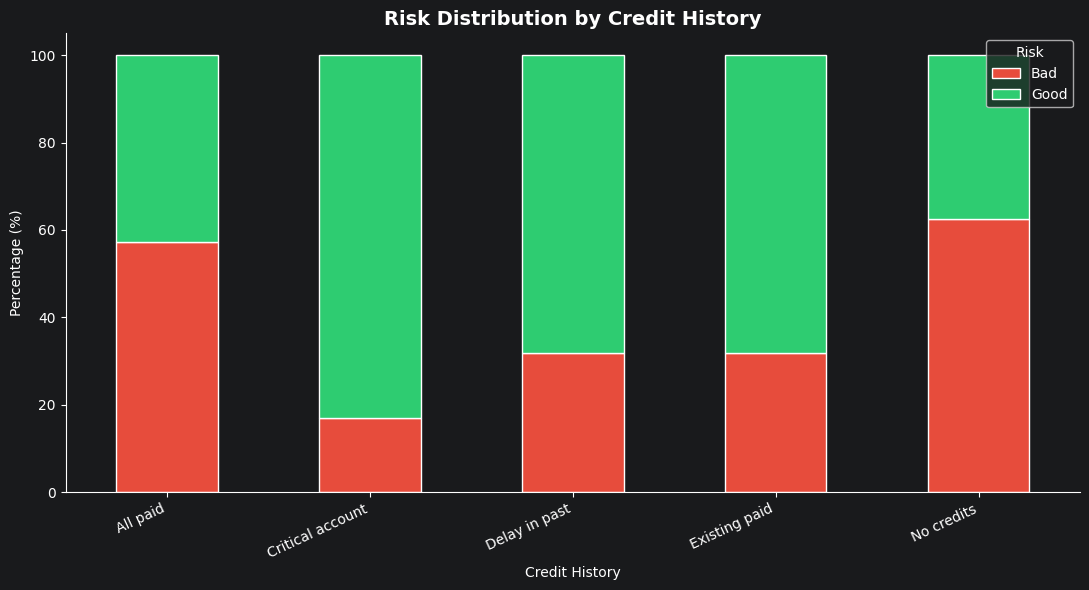

In [21]:
credit_history_labels = {
    'A30': 'No credits',
    'A31': 'All paid',
    'A32': 'Existing paid',
    'A33': 'Delay in past',
    'A34': 'Critical account'
}
df['credit_history_label'] = df['credit_history'].map(credit_history_labels)

ct = pd.crosstab(df['credit_history_label'], df['risk'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

ct_pct.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'],
            figsize=(11, 6), edgecolor='white')

plt.title('Risk Distribution by Credit History', fontsize=14, fontweight='bold')
plt.xlabel('Credit History')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Risk')
plt.tight_layout()
plt.show()

## 8. Chart: Correlation Heatmap

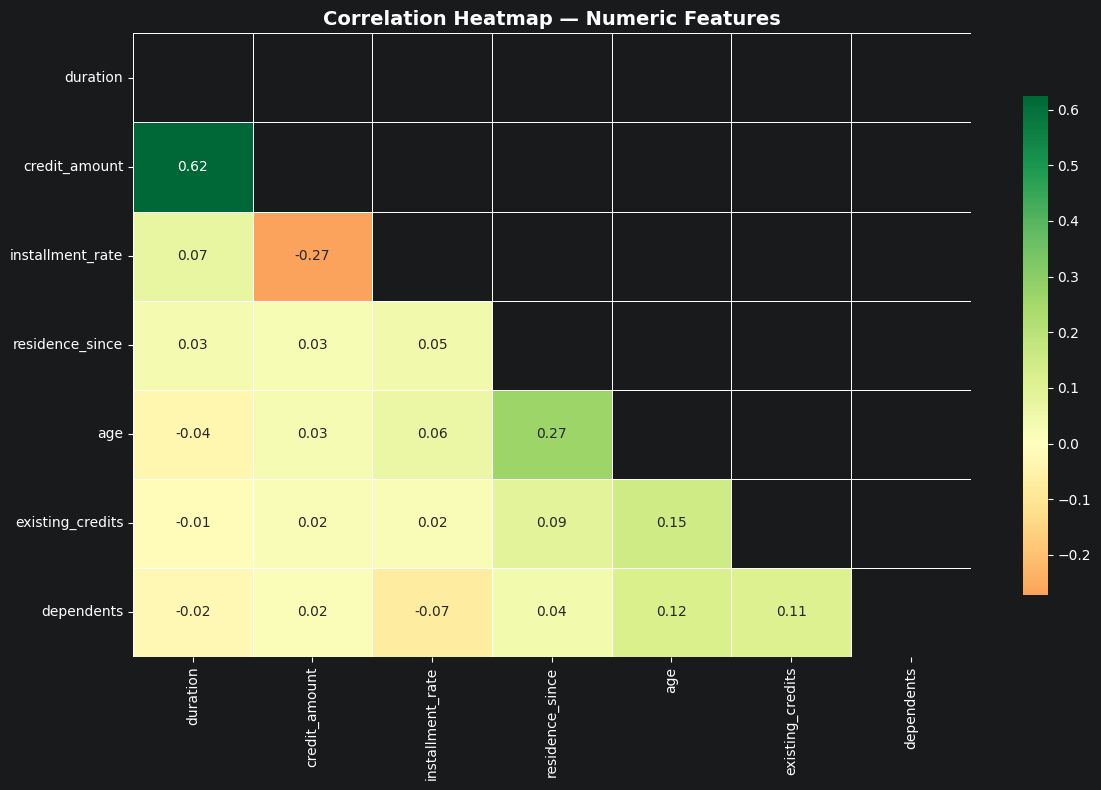

In [22]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Chart: Top Risk Factors (Average by Risk Group)

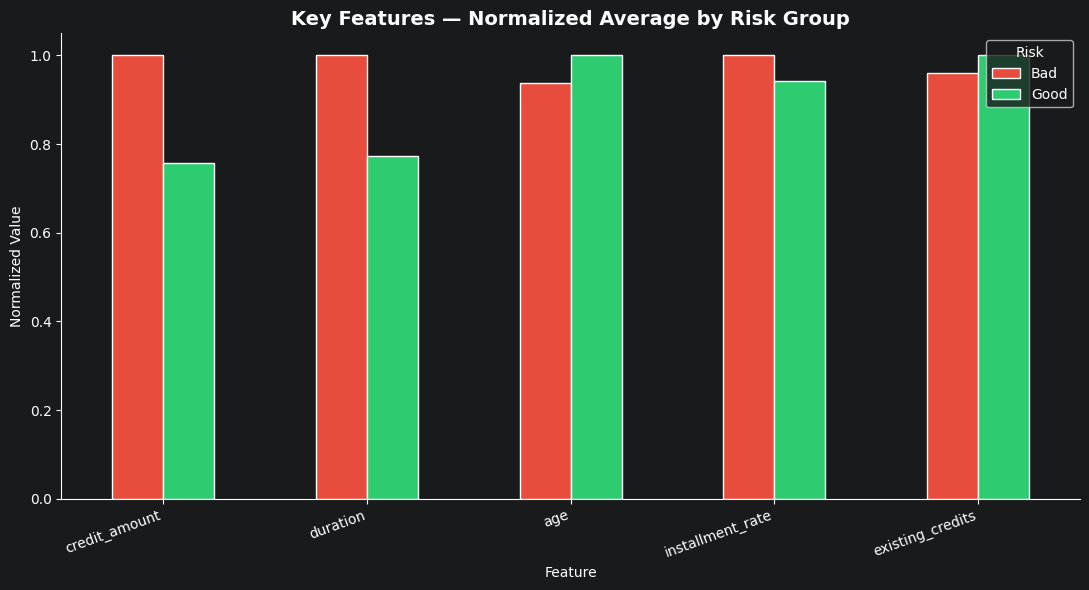

In [23]:
features = ['credit_amount', 'duration', 'age', 'installment_rate', 'existing_credits']
group_means = df.groupby('risk')[features].mean()

# Normalize for comparison
group_means_norm = group_means.div(group_means.max())

group_means_norm.T.plot(kind='bar', figsize=(11, 6),
                         color=['#e74c3c', '#2ecc71'], edgecolor='white')
plt.title('Key Features — Normalized Average by Risk Group', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Normalized Value')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Risk')
plt.tight_layout()
plt.show()

## 10. Summary Insights

In [11]:
print('=== KEY INSIGHTS ===')
print(f"Total records: {len(df)}")
print(f"Good risk: {(df['risk']=='Good').sum()} ({(df['risk']=='Good').mean()*100:.1f}%)")
print(f"Bad risk:  {(df['risk']=='Bad').sum()} ({(df['risk']=='Bad').mean()*100:.1f}%)")
print()
print('--- Credit Amount ---')
print(df.groupby('risk')['credit_amount'].agg(['mean', 'median']).round(0))
print()
print('--- Duration (months) ---')
print(df.groupby('risk')['duration'].agg(['mean', 'median']).round(1))
print()
print('--- Age ---')
print(df.groupby('risk')['age'].agg(['mean', 'median']).round(1))

=== KEY INSIGHTS ===
Total records: 1000
Good risk: 700 (70.0%)
Bad risk:  300 (30.0%)

--- Credit Amount ---
        mean  median
risk                
Bad   3938.0  2574.0
Good  2985.0  2244.0

--- Duration (months) ---
      mean  median
risk              
Bad   24.9    24.0
Good  19.2    18.0

--- Age ---
      mean  median
risk              
Bad   34.0    31.0
Good  36.2    34.0
